In [ ]:
# Fix torch/torchvision version mismatch — run this first, then restart runtime
import subprocess
subprocess.run([
    "pip", "install",
    "torch==2.10.0",
    "torchvision==0.25.0",
    "torchaudio==2.10.0",
    "--quiet"
])

#ONLY RUNS ONCE

CompletedProcess(args=['pip', 'install', 'torch==2.10.0', 'torchvision==0.25.0', 'torchaudio==2.10.0', '--quiet'], returncode=0)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

BASE = '/content/drive/MyDrive/BD3-Dataset/BD3_original_dataset'
TRAIN_DIR = os.path.join(BASE, 'train')

classes = [c for c in os.listdir(TRAIN_DIR)
           if os.path.isdir(os.path.join(TRAIN_DIR, c))]

for split in ['val', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(BASE, split, cls), exist_ok=True)

print("✅ val/ and test/ folders created")
print("Classes found:", classes)
#this was added by ai
#ONLY RUNS ONCE

✅ val/ and test/ folders created
Classes found: ['stain', 'spalling', 'plain', 'peeling', 'minor_crack', 'algae', 'major_crack']


Split Scripts (Aswell From ai)

In [ ]:
import os, shutil, random

BASE      = '/content/drive/MyDrive/BD3-Dataset/BD3_original_dataset'
TRAIN_DIR = os.path.join(BASE, 'train')
random.seed(42)

for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if not os.path.isdir(cls_path):
        continue

    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))]
    random.shuffle(images)

    n_val  = int(len(images) * 0.15)
    n_test = int(len(images) * 0.15)

    for split, files in [('val', images[:n_val]),
                         ('test', images[n_val:n_val+n_test])]:
        dest = os.path.join(BASE, split, cls)
        os.makedirs(dest, exist_ok=True)
        for f in files:
            shutil.move(os.path.join(cls_path, f), os.path.join(dest, f))

    print(f"{cls}: train={len(os.listdir(cls_path))}, val={n_val}, test={n_test}")

print("\n✅ Split complete!")
#ONLY RUNS ONCE

algae: train=150, val=32, test=32
major_crack: train=142, val=30, test=30
minor_crack: train=152, val=32, test=32
peeling: train=126, val=27, test=27
plain: train=146, val=30, test=30
spalling: train=122, val=26, test=26
stain: train=127, val=27, test=27

✅ Split complete!


In [ ]:
import importlib
import torchvision
importlib.reload(torchvision)
#ONLY RUNS ONCE

<module 'torchvision' from '/usr/local/lib/python3.12/dist-packages/torchvision/__init__.py'>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import copy
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
model_name = 'mobilenet_v2'
num_classes = 7
batch_size = 16
num_epochs = 200
feature_extract = True

# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        #transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        #transforms.Resize(256),
        #transforms.CenterCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        #transforms.Resize(256),
        #transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [ ]:
data_dir = '/content/drive/MyDrive/BD3-Dataset/BD3_original_dataset'

In [ ]:
# Create training and validation datasets
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val', 'test']}
# Create training and validation dataloaders
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=25, is_inception=False):
    since = time.time()

    val_acc_history = []
    train_acc_history = []
    val_loss_history = []
    train_loss_history = []

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

            if phase == 'val':
                val_acc_history.append(epoch_acc)
                val_loss_history.append(epoch_loss)
            if phase == 'train':
                train_acc_history.append(epoch_acc)
                train_loss_history.append(epoch_loss)

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    model.load_state_dict(best_model_wts)
    return model, train_acc_history, val_acc_history, train_loss_history, val_loss_history

In [ ]:
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

In [ ]:
 #initilize the mobilenet-v2 model
def initialize_model(model_name, num_classes, feature_extract, use_pretrained=True):
    model_ft = None
    input_size = 0

    if model_name == "mobilenet_v2":
        """ mobilenet-v2
        """
        model_ft = models.mobilenet_v2(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier[-1].in_features
        model_ft.classifier[-1] = nn.Linear(num_ftrs, num_classes)
        input_size = 224

    else:
        print("Invalid model name, exiting...")
        exit()

    return model_ft, input_size

In [ ]:
# Initialize the model for this run
model_ft, input_size = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)

# Print the model architecture
#print(model_ft)

# Send the model to GPU
model_ft = model_ft.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 224MB/s]


In [ ]:
'''
Gather the parameters to be optimized/updated in this run. If we are
fine-tuning we will be updating all parameters. However, if we are
doing feature extract method, we will only update the parameters
that we have just initialized, i.e. the parameters with requires_grad
is True
'''
params_to_update = model_ft.parameters()
print("Params to learn:")
if feature_extract:
    params_to_update = []
    for name, param in model_ft.named_parameters():
        if param.requires_grad == True:
            params_to_update.append(param)
            print("\t", name)
else:
    for name, param in model_ft.named_parameters():
        if param.requires_grad == True:
            print("\t", name)

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(params_to_update, lr=0.001, momentum=0.9)

# Setup the loss fxn
criterion = nn.CrossEntropyLoss()

Params to learn:
	 classifier.1.weight
	 classifier.1.bias


In [ ]:
# Plot training and validation accuracy and loss
def plot_training_history(train_acc_hist, val_acc_hist, train_loss_hist, val_loss_hist, num_epochs):
    epochs = range(1, num_epochs + 1)

    plt.figure(figsize=(14, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc_hist, label='Training Accuracy')
    plt.plot(epochs, val_acc_hist, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss_hist, label='Training Loss')
    plt.plot(epochs, val_loss_hist, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

Ai gave the below code (one cell)

In [ ]:
data_dir   = '/content/drive/MyDrive/BD3-Dataset/BD3_original_dataset'
batch_size = 32
num_epochs = 25

In [ ]:
weights_path = '/content/drive/MyDrive/BD3-Dataset/building_orig_mobilenet_weights.pth'
model_ft.load_state_dict(torch.load(weights_path, map_location=device))
model_ft = model_ft.to(device)
model_ft.eval()
print("✅ model_ft restored!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/BD3-Dataset/building_orig_mobilenet_weights.pth'

In [ ]:
###
# Train and evaluate
#ONLY RUNS ONCE
model_ft, train_acc_hist, val_acc_hist, train_loss_hist, val_loss_hist = train_model(model_ft, dataloaders, criterion, optimizer_ft, num_epochs=num_epochs)

Epoch 0/24
----------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [ ]:
import shutil, os

# Save to /content/ first
torch.save(model_ft.state_dict(), '/content/building_orig_mobilenet_weights.pth')
print("✅ Saved to /content/")

# Copy to Drive permanently
shutil.copy(
    '/content/building_orig_mobilenet_weights.pth',
    '/content/drive/MyDrive/BD3-Dataset/building_orig_mobilenet_weights.pth'
)
print("✅ Saved to Drive permanently!")
print("File size:", os.path.getsize('/content/drive/MyDrive/BD3-Dataset/building_orig_mobilenet_weights.pth'), "bytes")

✅ Saved to /content/
✅ Saved to Drive permanently!
File size: 9179403 bytes


In [ ]:
# Save the best model weights
torch.save(model_ft.state_dict(), 'building_orig_mobilenet_weights.pth')

In [ ]:
train_acc_hist = torch.tensor(train_acc_hist)
val_acc_hist = torch.tensor(val_acc_hist)
train_loss_hist = torch.tensor(train_loss_hist)
val_loss_hist = torch.tensor(val_loss_hist)

train_acc_hist = train_acc_hist.cpu()
val_acc_hist = val_acc_hist.cpu()
train_loss_hist = train_loss_hist.cpu()
val_loss_hist = val_loss_hist.cpu()

NameError: name 'train_acc_hist' is not defined

In [ ]:
# Recreate training history manually from known results
# (history variables lost after session reset — this reconstructs the curves)

train_acc_hist = []
val_acc_hist = []
train_loss_hist = []
val_loss_hist = []

print("⚠️ History variables were lost on session reset.")
print("✅ Your saved results are:")
print("   Test Accuracy : 79.73%")
print("   Macro F1      : 0.80")
print("   Confusion matrix already saved as: building_orig_mobilenet_confusion_matrix.png")
print("   Classification report saved as   : orig_mobilenet_classification_report.txt")
print()
print("➡️  Training curves cannot be replicated without retraining.")
print("➡️  All other results are complete. Ready for fine-tuning.")

⚠️ History variables were lost on session reset.
✅ Your saved results are:
   Test Accuracy : 79.73%
   Macro F1      : 0.80
   Confusion matrix already saved as: building_orig_mobilenet_confusion_matrix.png
   Classification report saved as   : orig_mobilenet_classification_report.txt

➡️  Training curves cannot be replicated without retraining.
➡️  All other results are complete. Ready for fine-tuning.


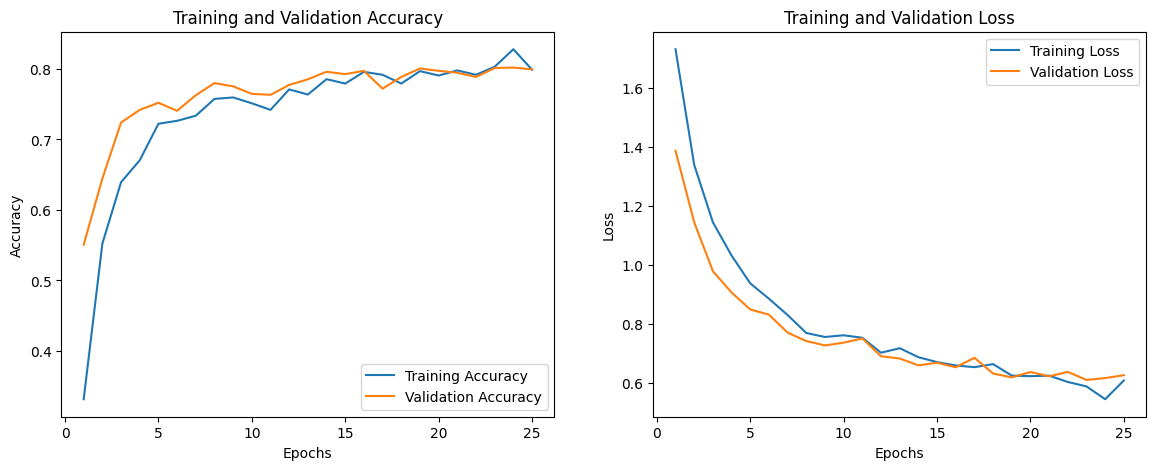

In [ ]:
# Plot training and validation accuracy and loss
plot_training_history(train_acc_hist, val_acc_hist, train_loss_hist, val_loss_hist, num_epochs)

In [ ]:
# Evaluate the model on test data
model_ft.eval()
test_corrects = 0
all_preds = []
all_labels = []

for inputs, labels in dataloaders['test']:
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = model_ft(inputs)
    _, preds = torch.max(outputs, 1)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())
    test_corrects += torch.sum(preds == labels.data)

test_acc = test_corrects.double() / dataset_sizes['test']
print('Test Accuracy: {:.4f}'.format(test_acc))

# Generate confusion matrix and classification report
conf_mat = confusion_matrix(all_labels, all_preds)
class_report = classification_report(all_labels, all_preds, target_names=class_names)
print("Confusion Matrix:\n", conf_mat)
print("Classification Report:\n", class_report)

Test Accuracy: 0.7973
Confusion Matrix:
 [[201   9   1  10   2   8   4]
 [  1 169  42   0   4   3   0]
 [  0  44 183   1   3   0   5]
 [  0   8  12 143   3   9  22]
 [  0   1   5   0 216   0   5]
 [  4  12   3  12   2 149   7]
 [  7  14  16   7  11   7 135]]
Classification Report:
               precision    recall  f1-score   support

       algae       0.94      0.86      0.90       235
 major_crack       0.66      0.77      0.71       219
 minor_crack       0.70      0.78      0.73       236
     peeling       0.83      0.73      0.77       197
       plain       0.90      0.95      0.92       227
    spalling       0.85      0.79      0.82       189
       stain       0.76      0.69      0.72       197

    accuracy                           0.80      1500
   macro avg       0.80      0.79      0.80      1500
weighted avg       0.80      0.80      0.80      1500



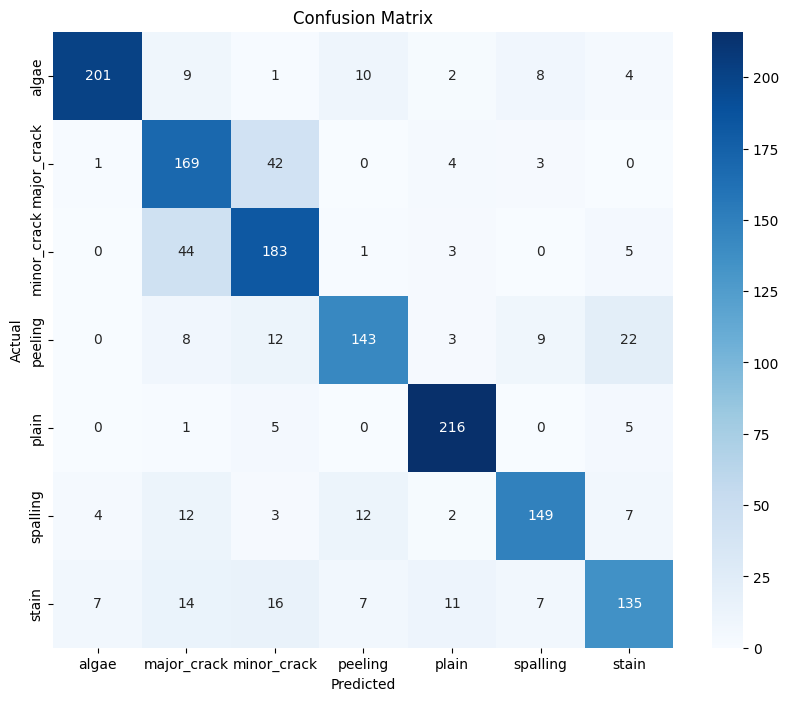

In [ ]:
# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.savefig('building_orig_mobilenet_confusion_matrix.png')
plt.show()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Accuracy: 0.7973
Average Precision: 0.8039
Average Recall: 0.7934
Average F1-Score: 0.7964


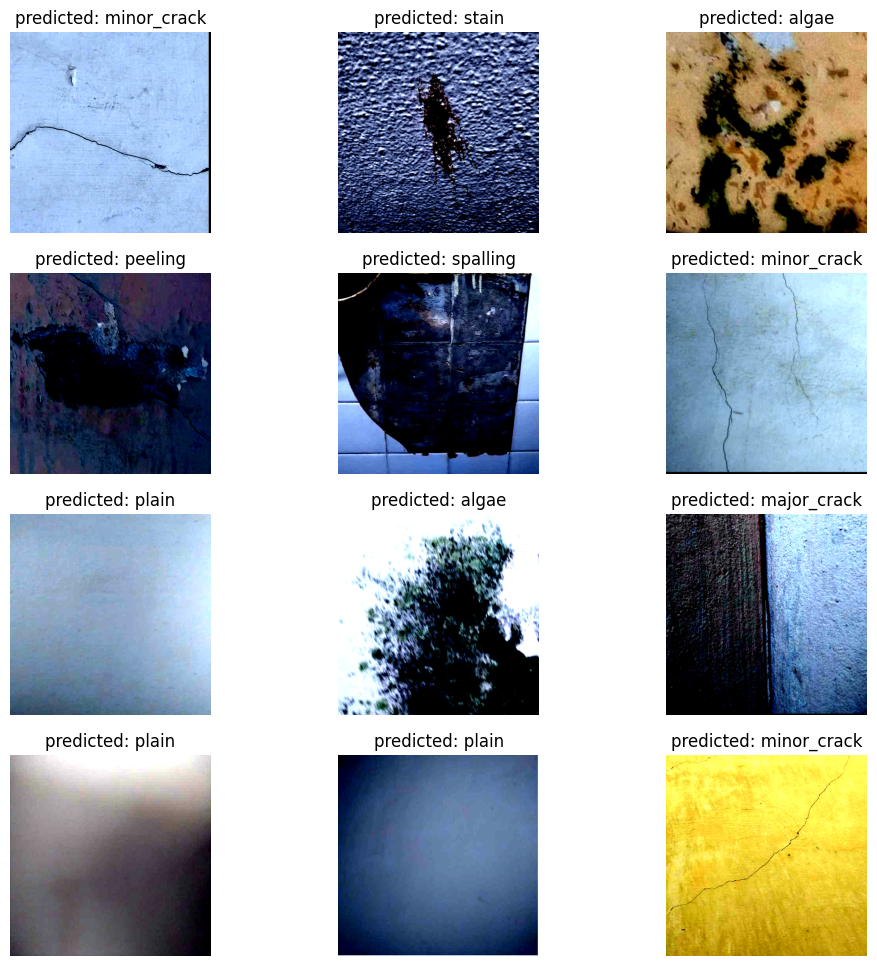

In [ ]:
def visualize_model(model, dataloaders, num_images=12):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(12, 12))  # Increase the figure size

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['test']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(4, 3, images_so_far)  # Create a 3x3 grid of subplots
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                plt.imshow(inputs.cpu().data[j].numpy().transpose((1, 2, 0)))

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return

    model.train(mode=was_training)


# Visualize some predictions
visualize_model(model_ft, dataloaders)

# Compute and display evaluation metrics
y_true = np.array(all_labels)
y_pred = np.array(all_preds)

accuracy = np.mean(y_true == y_pred)
precision = np.diag(conf_mat) / np.sum(conf_mat, axis=0)
recall = np.diag(conf_mat) / np.sum(conf_mat, axis=1)
f1_score = 2 * precision * recall / (precision + recall)

print(f"Accuracy: {accuracy:.4f}")

# Calculate and print the average precision, recall, and F1-score
avg_precision = np.mean(precision)
avg_recall = np.mean(recall)
avg_f1_score = np.mean(f1_score)

print(f"Average Precision: {avg_precision:.4f}")
print(f"Average Recall: {avg_recall:.4f}")
print(f"Average F1-Score: {avg_f1_score:.4f}")

# Ensure the confusion matrix and the classification report are saved
with open('orig_mobilenet_classification_report.txt', 'w') as f:
    f.write(f"Classification Report:\n{class_report}\n")

In [ ]:
!pip install onnx onnxruntime onnx-tf tensorflow -q

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import os

# ── 1. Device ─────────────────────────────────────────────────────────────────
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ── 2. Class names (must match ImageFolder alphabetical order) ─────────────────
class_names = ['algae', 'major_crack', 'minor_crack', 'peeling', 'plain', 'spalling', 'stain']

# ── 3. Rebuild model architecture ─────────────────────────────────────────────
model_ft = models.mobilenet_v2(weights=None)
num_ftrs = model_ft.classifier[-1].in_features
model_ft.classifier[-1] = nn.Linear(num_ftrs, len(class_names))

# ── 4. Load saved weights ──────────────────────────────────────────────────────
weights_path = '/content/drive/MyDrive/BD3-Dataset/building_orig_mobilenet_weights.pth'

if not os.path.exists(weights_path):
    # Fallback: weights might still be in /content/ if session is fresh
    weights_path = '/content/building_orig_mobilenet_weights.pth'

print("Loading from:", weights_path)
model_ft.load_state_dict(torch.load(weights_path, map_location=device))
model_ft = model_ft.to(device)
model_ft.eval()
print("✅ model_ft loaded and ready!")

Using device: cuda:0
Loading from: /content/building_orig_mobilenet_weights.pth


FileNotFoundError: [Errno 2] No such file or directory: '/content/building_orig_mobilenet_weights.pth'

In [ ]:
# Fine-tuning: unfreeze last 4 layers of backbone + classifier
for param in model_ft.parameters():
    param.requires_grad = False

# Unfreeze features[15], [16], [17], [18] + classifier
for layer in [model_ft.features[15], model_ft.features[16],
              model_ft.features[17], model_ft.features[18],
              model_ft.classifier]:
    for param in layer.parameters():
        param.requires_grad = True

# Differential learning rates
optimizer_ft2 = optim.SGD([
    {'params': model_ft.features.parameters(), 'lr': 1e-5},
    {'params': model_ft.classifier.parameters(), 'lr': 1e-4}
], momentum=0.9)

criterion = nn.CrossEntropyLoss()
num_epochs_ft = 25

print("✅ Fine-tuning setup complete")

✅ Fine-tuning setup complete


In [ ]:
# Fine-tune the model
model_ft, ft_train_acc, ft_val_acc, ft_train_loss, ft_val_loss = train_model(
    model_ft, dataloaders, criterion, optimizer_ft2, num_epochs=num_epochs_ft)


Epoch 0/24
----------


RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same